# Predict Beats Per Minute


regression with root mean squre error

## Setup

In [1]:
import pandas as pd


## Load data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv
Saving test.csv to test.csv


In [3]:
train_set, test_set = uploaded['train.csv'], uploaded['test.csv']

In [4]:
import io

train_df, test_df = pd.read_csv(io.BytesIO(train_set)), pd.read_csv(io.BytesIO(test_set))
train_df

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...,...
524159,524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


In [42]:
# drop ids
test_df = test_df.drop('id', axis=1)
train_df = train_df.drop('id', axis=1)

## EDA

In [43]:
test_df

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067
...,...,...,...,...,...,...,...,...,...
174717,0.332976,-9.654381,0.155402,0.143983,0.351255,0.307580,0.679634,255610.4189,0.427533
174718,0.828106,-11.143536,0.121822,0.451146,0.096678,0.140123,0.274977,241204.9403,0.098333
174719,0.569334,-4.253765,0.137968,0.246896,0.079425,0.102919,0.569331,127422.2955,0.193200
174720,0.764595,-11.088025,0.055225,0.430128,0.006836,0.105584,0.653928,171586.5838,0.067467


In [53]:
train_df

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...
524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


In [56]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 40.0 MB


In [52]:
train_df.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [64]:
train_df.corr(method='spearman')['BeatsPerMinute'].sort_values()

,BeatsPerMinute
Energy,-0.003420
AudioLoudness,-0.002379
AcousticQuality,-0.000072
InstrumentalScore,0.002638
VocalContent,0.003559
LivePerformanceLikelihood,0.004368
RhythmScore,0.005916
MoodScore,0.006694
TrackDurationMs,0.006901
BeatsPerMinute,1.000000


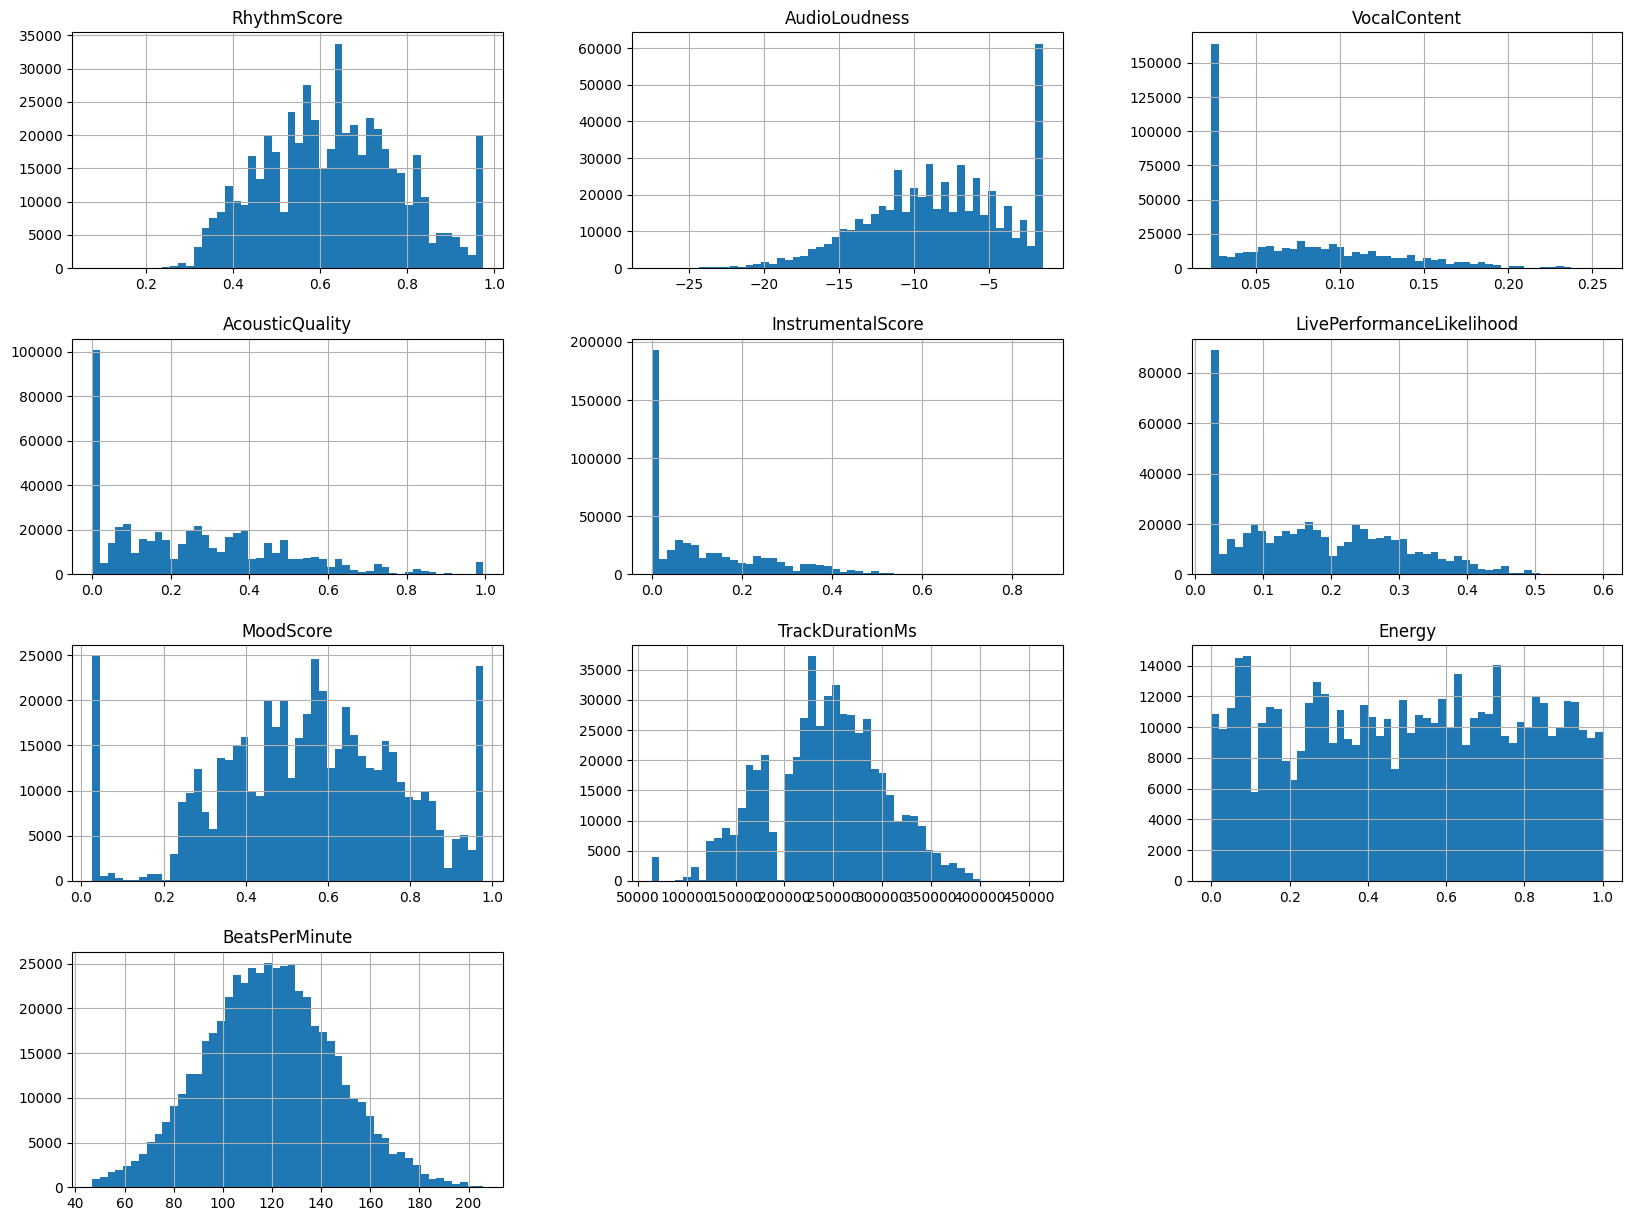

In [55]:
import matplotlib.pyplot as plt

train_df.hist(bins=50, figsize=(20,15))
plt.show()

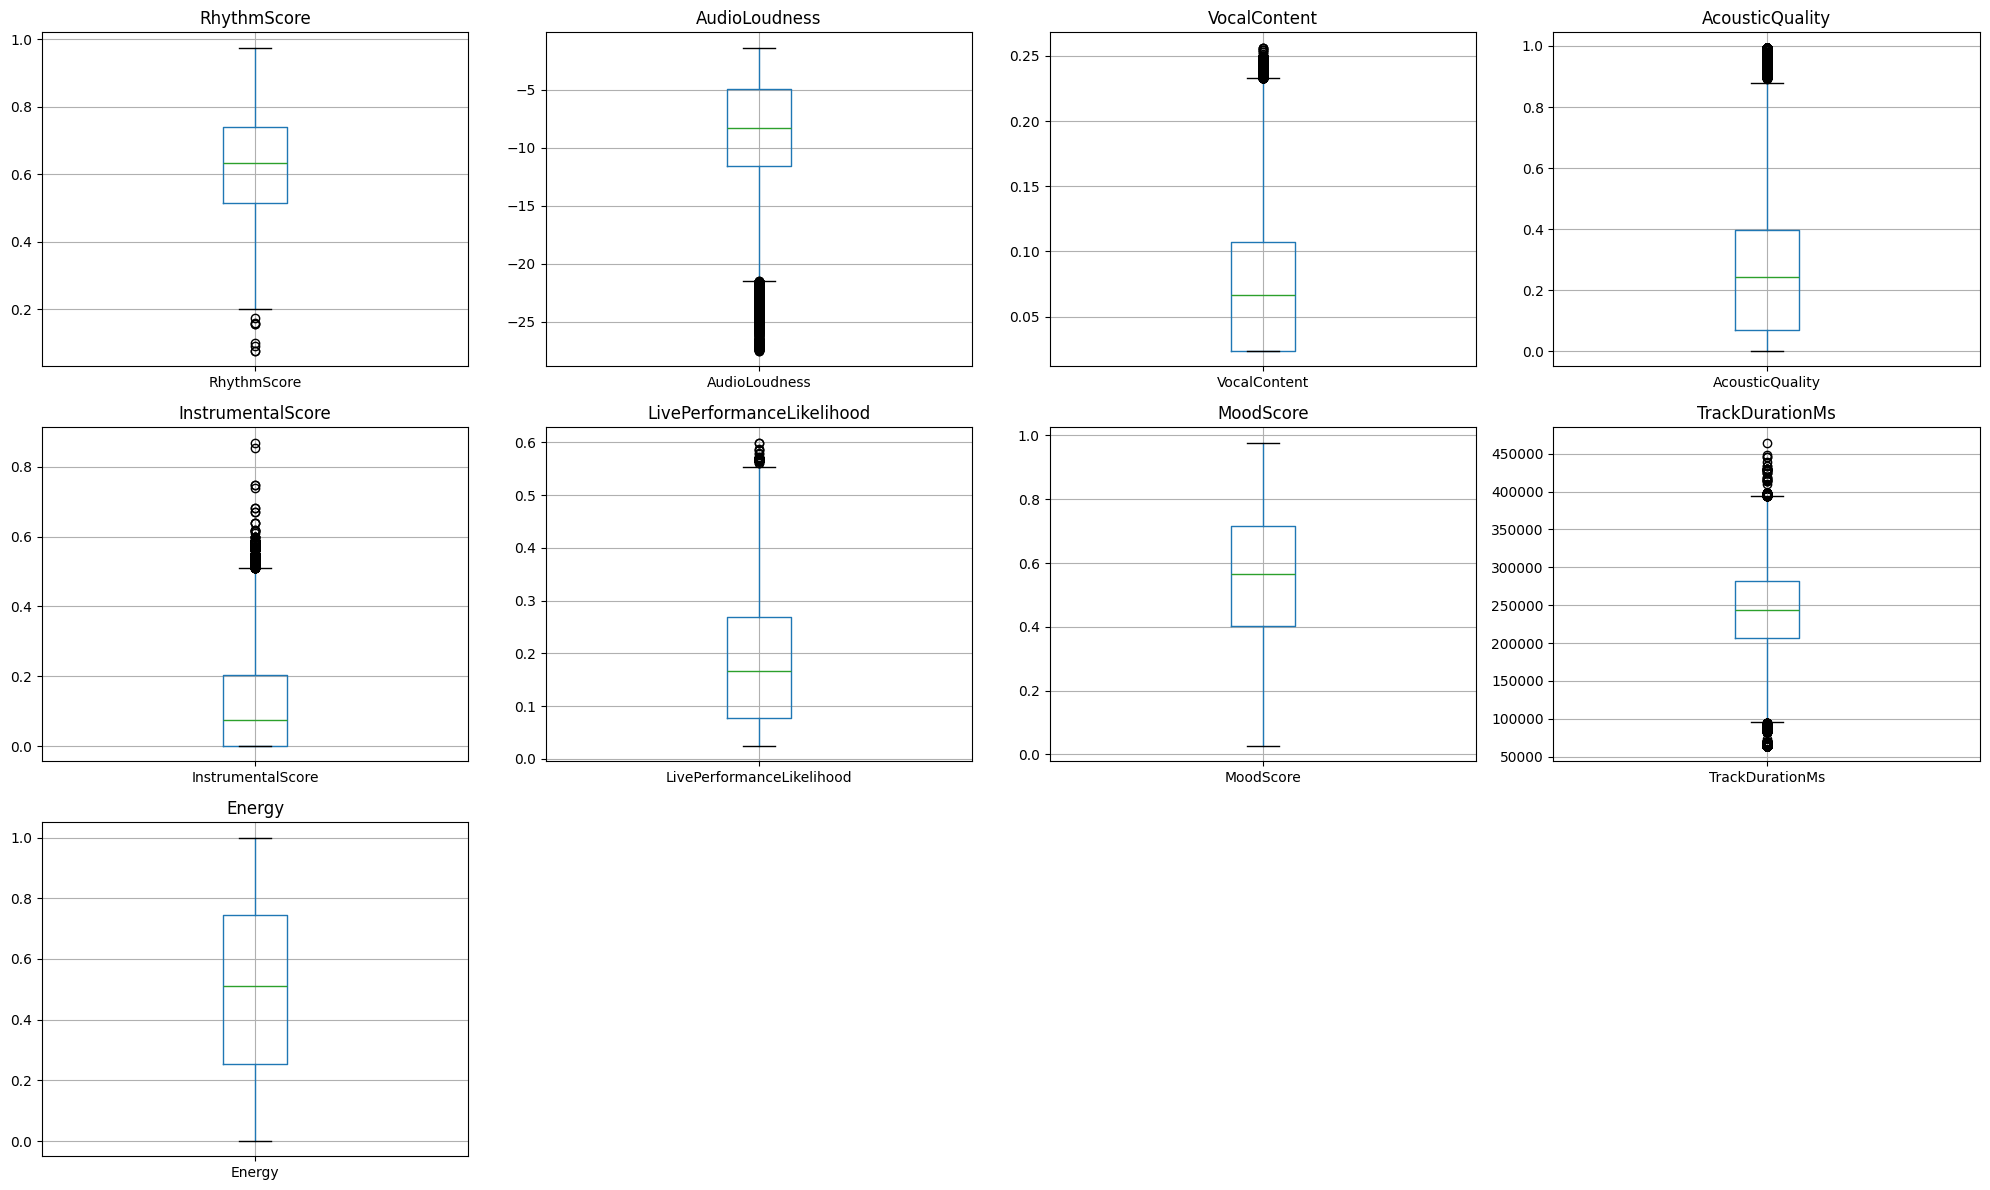

In [67]:
import math

num_cols = train_df.select_dtypes(include='number').columns
num_cols = [c for c in num_cols if c != 'BeatsPerMinute']

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    train_df.boxplot(column=col, ax=ax)
    ax.set_title(col)

# Remove empty subplots
for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


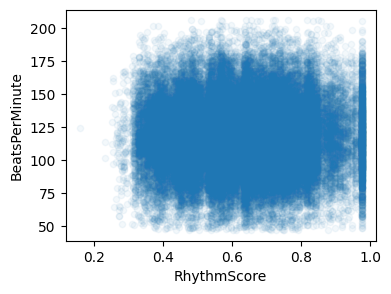

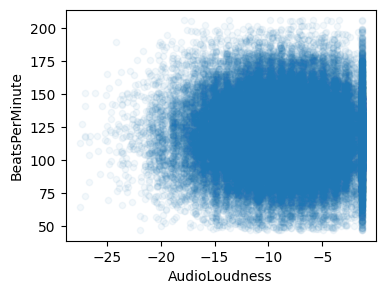

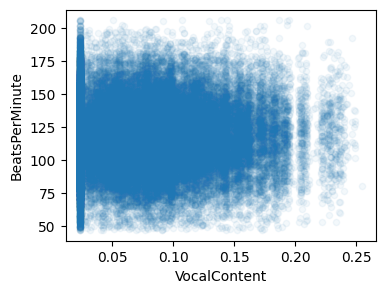

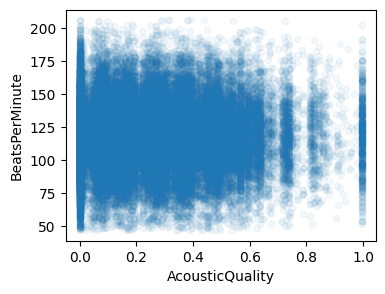

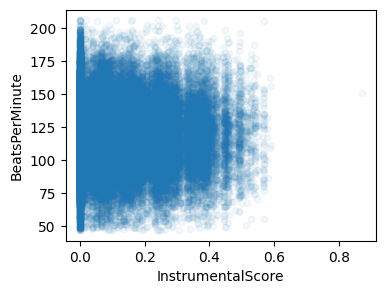

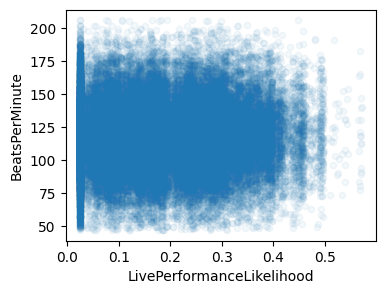

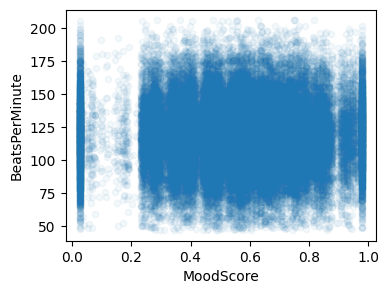

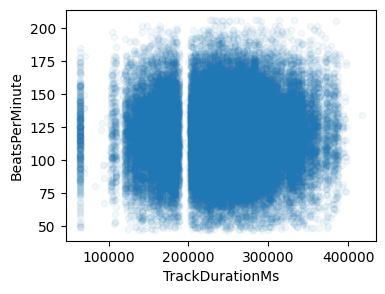

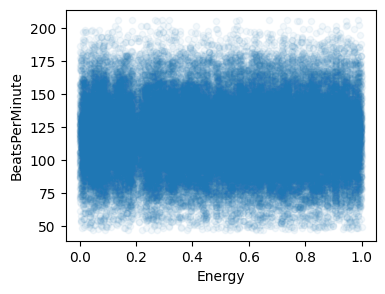

In [66]:
sample = train_df.sample(50000, random_state=42)

for col in num_cols:
    if col != 'BeatsPerMinute':
        sample.plot.scatter(
            x=col, y='BeatsPerMinute',
            alpha=0.05, figsize=(4,3)
        )
        plt.show()


### Label

<Axes: >

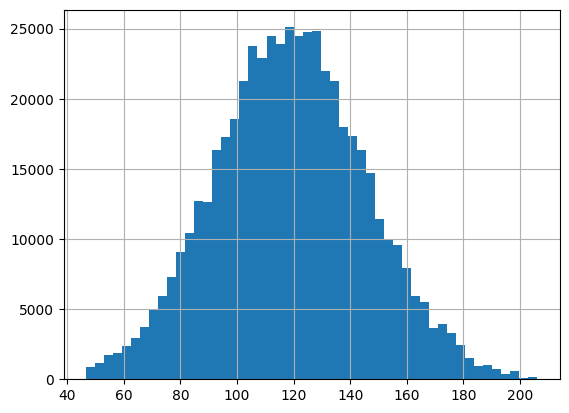

In [ ]:
train_df['BeatsPerMinute'].hist(bins=50)
# - fine

### Features

#### RhythmScore

<Axes: >

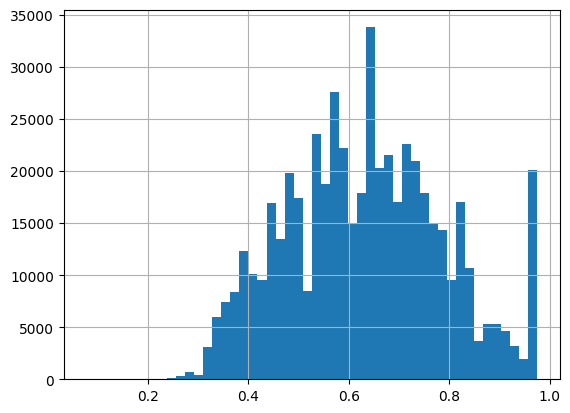

In [ ]:
train_df['RhythmScore'].hist(bins=50)
# continuous
# fine for now, can be more uniformly normalized with StandardScaler for linear and NNs

- Unimodal, roughly bell-shaped
- Bounded [0, 1]
- No heavy tails
- No spike at 0 or 1 → not clipped
- Mild unevenness = sampling noise, not a problem

=> **healthy feature**.

In [ ]:
train_df['RhythmScore'].describe()

,RhythmScore
count,524164.000000
mean,0.632843
std,0.156899
min,0.076900
25%,0.515850
50%,0.634686
75%,0.739179
max,0.975000


- Scale & range: bounded [0.076900; 0.975000], not need to normalize
- Disctribution shape: mean = median (50%),approx => roughly symmetric, no strong skew
- Variability: moderate spread ( CV (coefficient of variation) = 0.157/0.63=0.25 => 0.1 ≤ CV ≤ 0.3 → moderate spread)
- Outliers? max close to 1, min is not too extreme => no obviouse outlier problem


Outliers:

<Axes: >

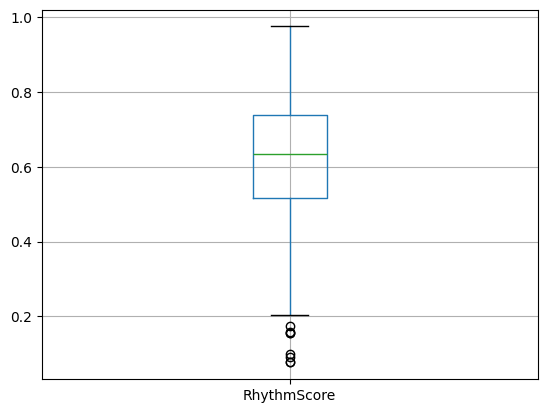

In [ ]:
train_df.boxplot('RhythmScore')

- Median ≈ 0.63
- IQR ~ 0.52-0.74 → good spread
- A few low-end outliers (~0.08-0.18)
- Upper end clean (no extreme high outliers)

These “outliers” are valid values, not errors.

In [ ]:
Q1 = train_df['RhythmScore'].quantile(0.25)
Q3 = train_df['RhythmScore'].quantile(0.75)
IQR = Q3 - Q1

outliers = train_df[
    (train_df['RhythmScore'] < Q1 - 1.5*IQR) |
    (train_df['RhythmScore'] > Q3 + 1.5*IQR)
]
outliers

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
317326,317326,0.158827,-6.812946,0.023500,0.434630,0.167940,0.107725,0.025600,271491.5754,0.974000,124.44727
368573,368573,0.155926,-6.381575,0.023500,0.044965,0.351720,0.262717,0.025600,238728.5074,0.994000,115.95490
388492,388492,0.155926,-3.538944,0.023500,0.451428,0.227623,0.024300,0.616675,273031.6859,0.955000,104.91968
391345,391345,0.099479,-12.113795,0.023500,0.494568,0.002984,0.134086,0.025600,292775.0856,0.983733,137.06231
404581,404581,0.076900,-16.818981,0.079653,0.000005,0.064712,0.082918,0.639004,243784.2442,0.993600,108.83709
440983,440983,0.174868,-15.037207,0.023500,0.613323,0.000001,0.024300,0.730938,263055.9275,0.513867,125.48969
499041,499041,0.090608,-11.907191,0.023500,0.274945,0.351848,0.300867,0.474038,176710.4545,0.964133,138.52698
515137,515137,0.076900,-12.967227,0.023500,0.000005,0.066012,0.247514,0.737340,293365.0756,0.997800,114.78564


Correlation with target

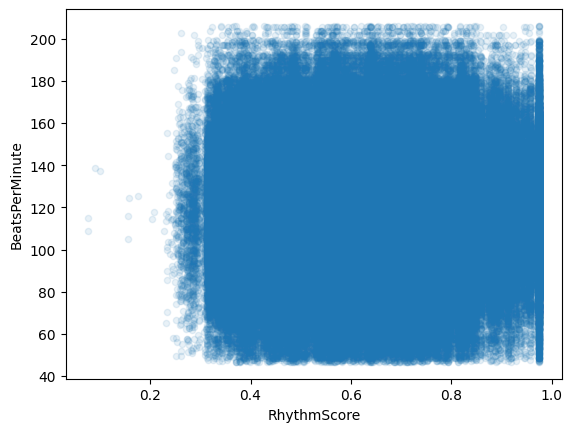

In [8]:
train_df.plot.scatter(x='RhythmScore', y='BeatsPerMinute', alpha=0.1)
plt.show()

<Axes: xlabel='RhythmScore', ylabel='BeatsPerMinute'>

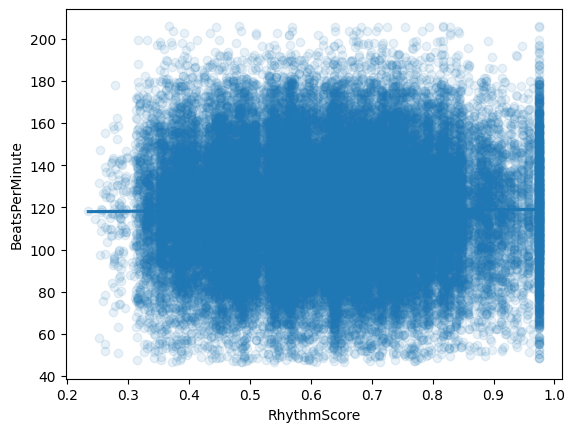

In [9]:
# Non-linear visualization
import seaborn as sns
sns.regplot(
    data=train_df.sample(50000),
    x='RhythmScore',
    y='BeatsPerMinute',
    lowess=True,
    scatter_kws={'alpha':0.1}
)

- Almost no visible relationship
- BPM spans ~40-200 for all RhythmScore values
- Vertical “wall” → RhythmScore is bounded, BPM is not
- This feature alone cannot predict BPM
- no need for monotonic transforms (log(x), sqrt(x), exp(x), power transforms, rank / quantile transforms)

In [ ]:
# Spearman
train_df[['RhythmScore', 'BeatsPerMinute']].corr(method='spearman')

,RhythmScore,BeatsPerMinute
RhythmScore,1.000000,0.005916
BeatsPerMinute,0.005916,1.000000


Conclusion: keep as is for tree based model
Try interactions with other features for linear model

#### AudioLoudness

<Axes: >

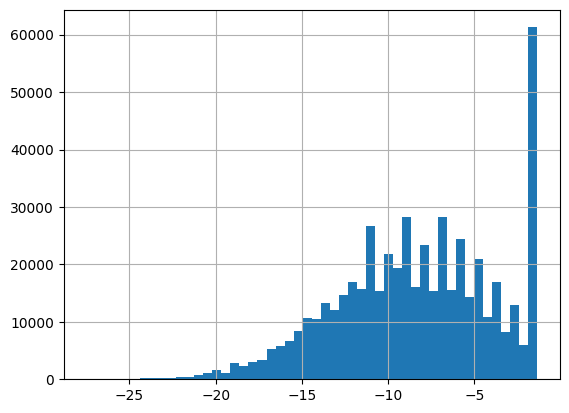

In [10]:
train_df['AudioLoudness'].hist(bins=50)
# - negative values => sqrt/log is not approriate here since they work on positive values
# Do nothing for tree models
# standardize for linear/ NNs. Standard scaler is fine.

left-skewed (valid, not errors), hard upper bound near 0 (also valid)
Trees handle skews + bounds

Or: Standardize for linear

Standardize or Yeo-Johnson if model is sensitive for NN models

In [11]:
train_df['AudioLoudness'].describe()

,AudioLoudness
count,524164.000000
mean,-8.379014
std,4.616221
min,-27.509725
25%,-11.551933
50%,-8.252499
75%,-4.912298
max,-1.357000


high spread - left skewed

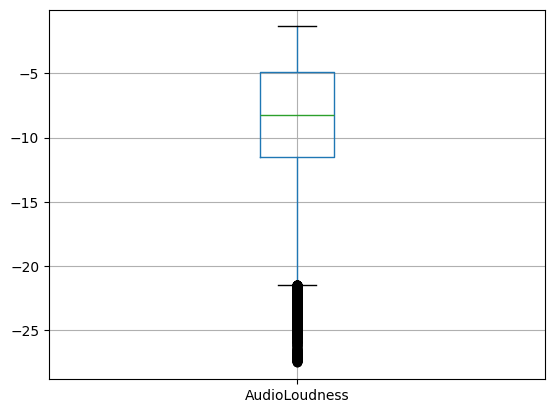

In [14]:
train_df.boxplot('AudioLoudness')
plt.show()

Outliers are valid part of the feature

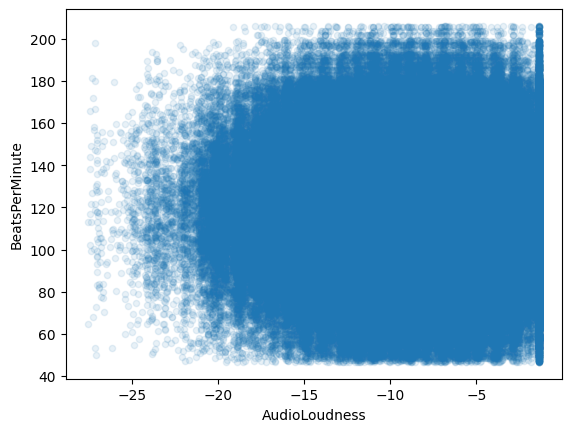

In [16]:
train_df.plot.scatter(x='AudioLoudness', y='BeatsPerMinute', alpha=0.1)
plt.show()

In [17]:
train_df[['AudioLoudness', 'BeatsPerMinute']].corr(method='spearman')

,AudioLoudness,BeatsPerMinute
AudioLoudness,1.000000,-0.002379
BeatsPerMinute,-0.002379,1.000000


AudioLoudness has no monotonic relationship with BeatsPerMinute
Tree/Boosting might detect interaction, for linear add interactions

#### VocalContent

In [18]:
train_df['VocalContent'].describe()

,VocalContent
count,524164.000000
mean,0.074443
std,0.049939
min,0.023500
25%,0.023500
50%,0.066425
75%,0.107343
max,0.256401


<Axes: >

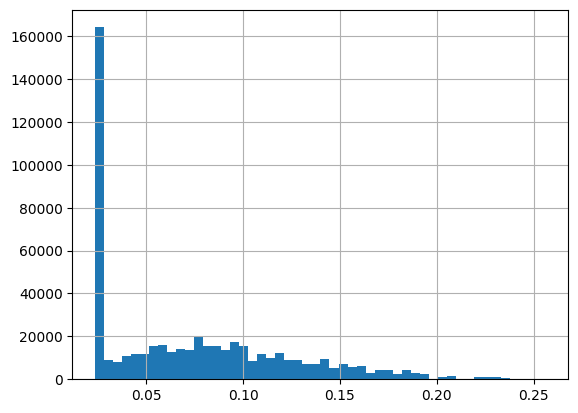

In [19]:
train_df['VocalContent'].hist(bins=50)

<Axes: >

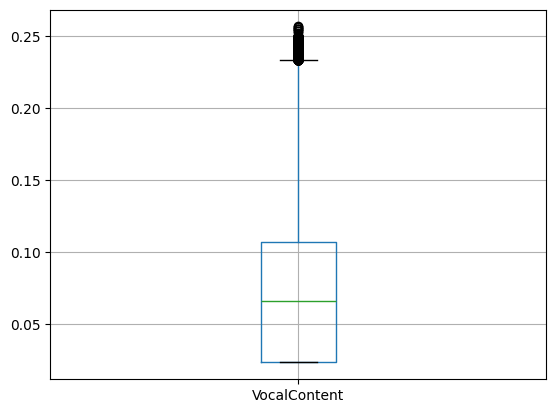

In [21]:
train_df.boxplot(['VocalContent'])

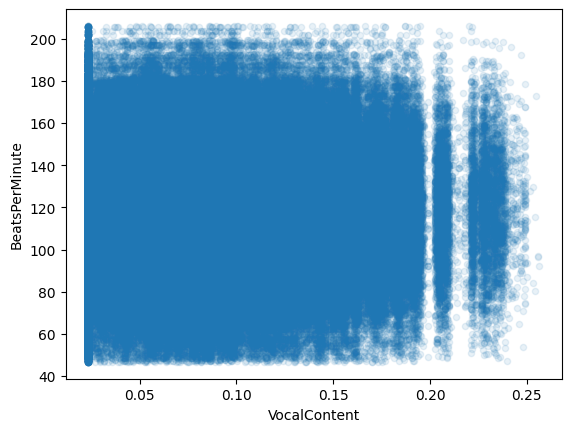

In [28]:
train_df.plot.scatter(x='VocalContent', y='BeatsPerMinute', alpha=0.1)
plt.show()

In [31]:
train_df[['VocalContent', 'BeatsPerMinute']].corr(method='spearman')

,VocalContent,BeatsPerMinute
VocalContent,1.000000,0.003559
BeatsPerMinute,0.003559,1.000000


#### AcousticQuality

In [32]:
train_df['AcousticQuality'].describe()

,AcousticQuality
count,524164.000000
mean,0.262913
std,0.223120
min,0.000005
25%,0.069413
50%,0.242502
75%,0.396957
max,0.995000


<Axes: >

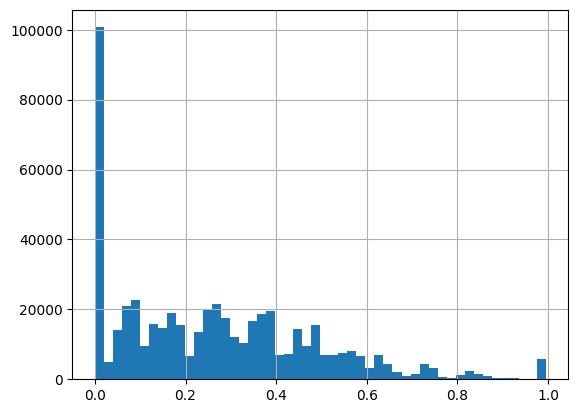

In [33]:
train_df['AcousticQuality'].hist(bins=50)

<Axes: >

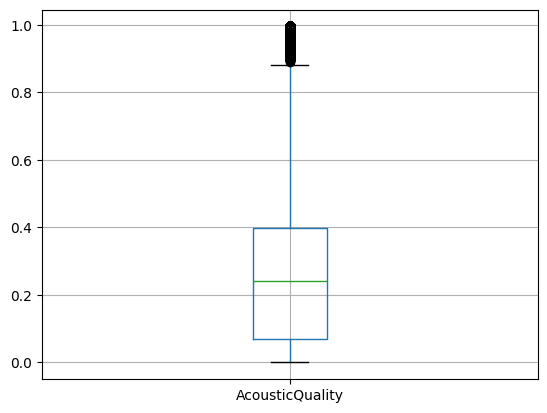

In [34]:
train_df.boxplot('AcousticQuality')

[]

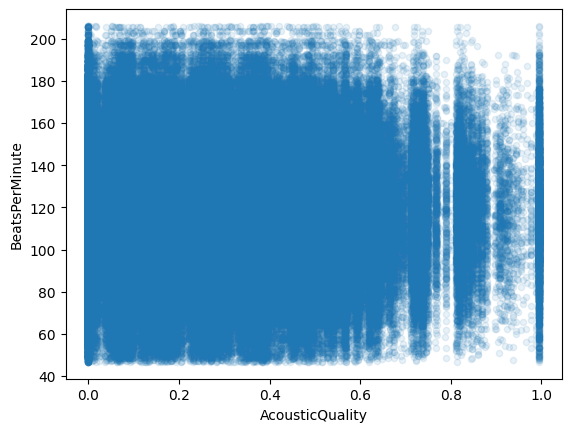

In [36]:
train_df.plot.scatter(x='AcousticQuality', y='BeatsPerMinute', alpha=0.1)
plt.plot()

#### 	InstrumentalScore	LivePerformanceLikelihood	MoodScore	TrackDurationMs	Energy